In [4]:
!pip install lifelines shap xgboost -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.5 MB/s eta 0:00:00


Saving chemotherapy_patient_data.csv to chemotherapy_patient_data (5).csv
Dataset Loaded Successfully!
  Patient_ID  Age     Sex   BMI Smoking_Status Cancer_Type Genetic_Mutation  \
0     P00001   68    Male  31.5         Former      Breast            BRCA1   
1     P00002   81  Female  25.8         Former        Lung             KRAS   
2     P00003   58    Male  22.3         Former    Lymphoma            BRCA1   
3     P00004   44    Male  33.6          Never    Lymphoma             EGFR   
4     P00005   72    Male  23.7          Never      Breast             TP53   

  Tumor_Stage  Tumor_Size Metastasis_Status Chemotherapy_Regimen  \
0          II         8.8                No               FOLFOX   
1           I         5.4               Yes                 CHOP   
2          II         3.3                No                 ABVD   
3          IV         6.0                No               FOLFOX   
4         III         5.7                No               FOLFOX   

   Dosage (mg

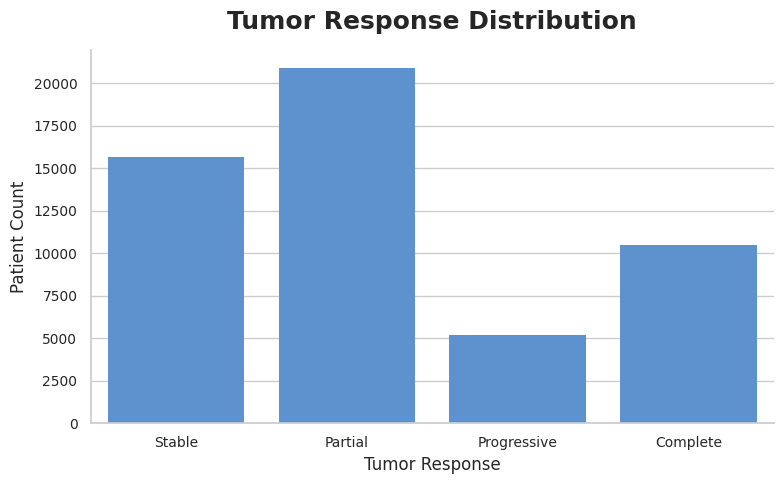

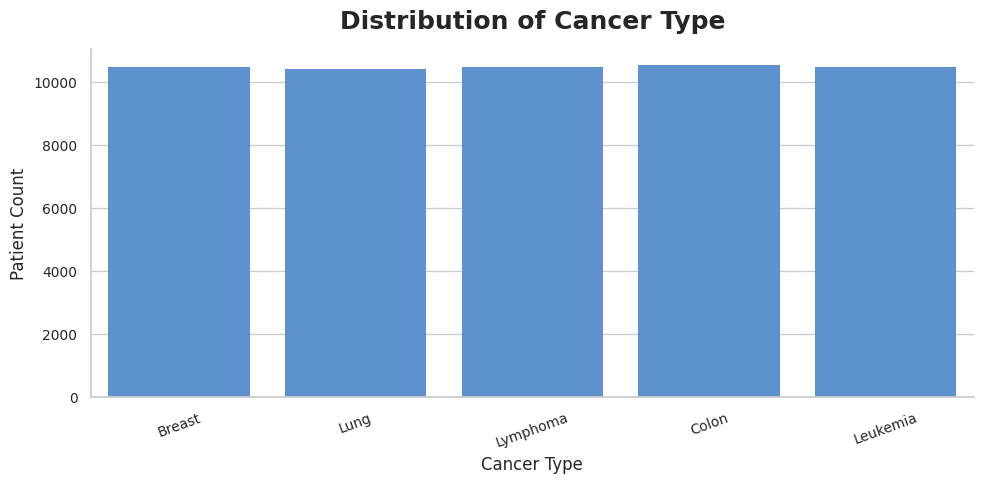

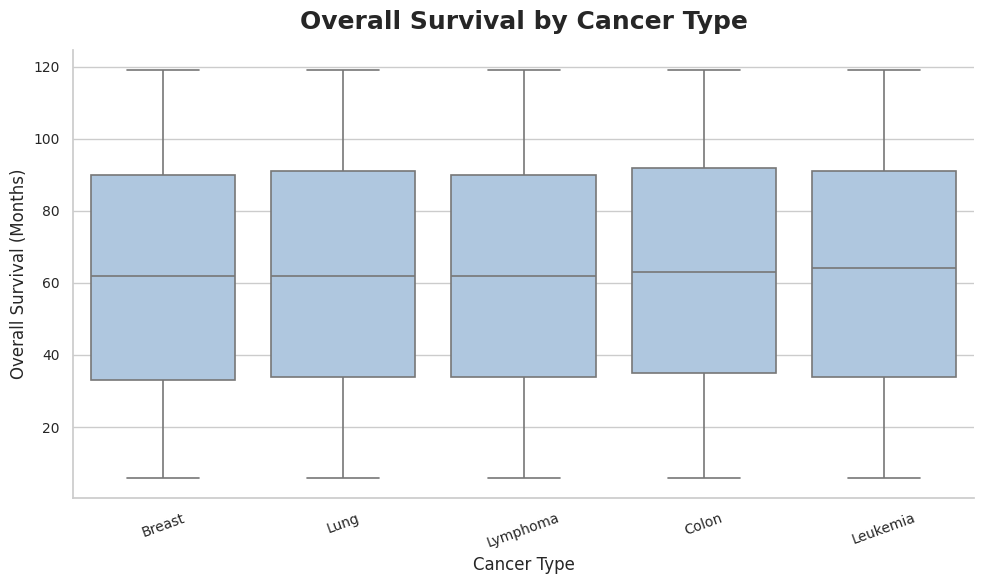

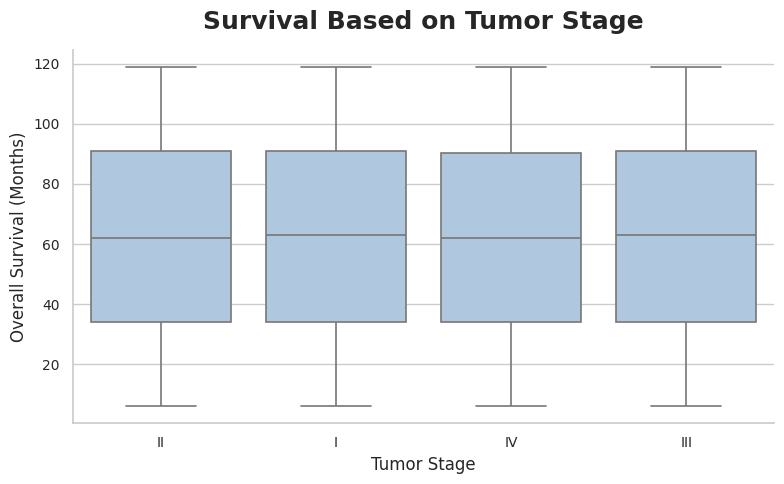

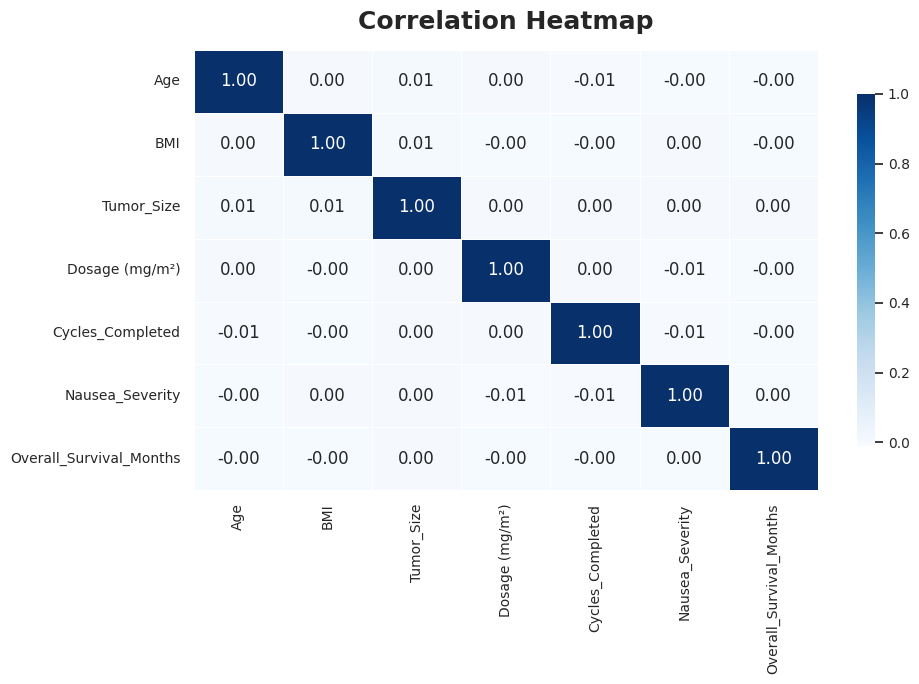


================ SURVIVAL ANALYSIS ================



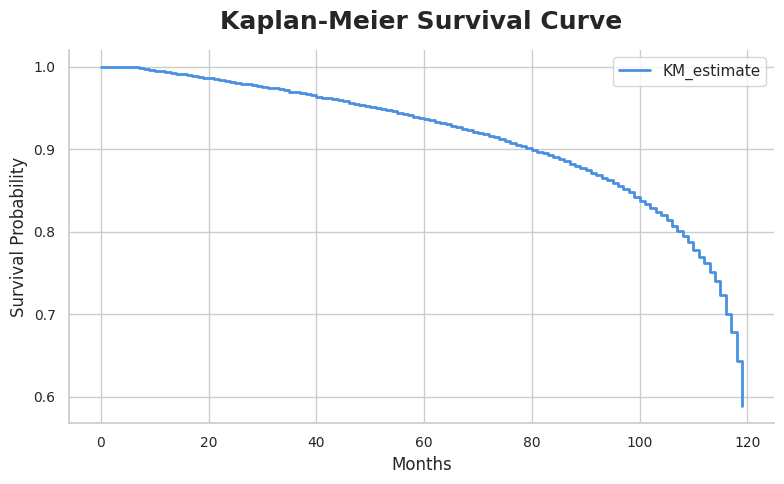


================ PATIENT SEGMENTATION ================

Patient_Segment
2    17655
1    17434
0    17232
Name: count, dtype: int64


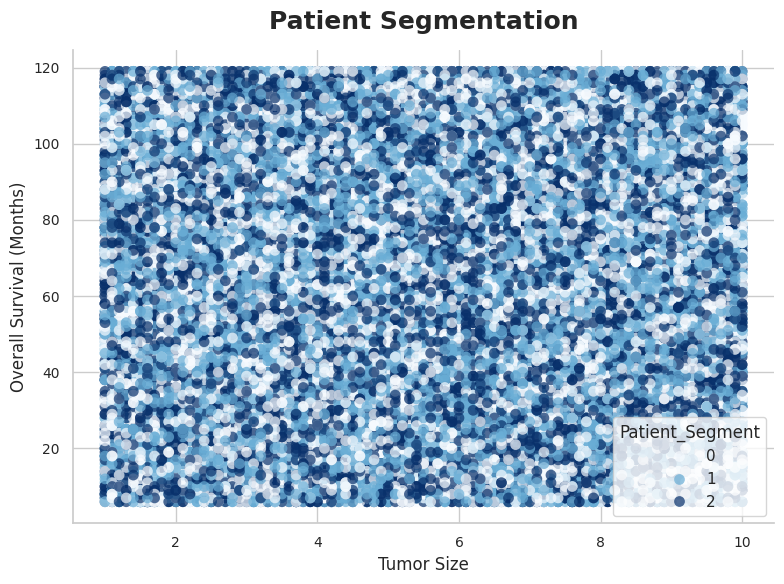


================ MACHINE LEARNING ================


Model Accuracy: 0.3981

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.13      0.00      0.00      2100
           1       0.40      0.96      0.57      4185
           2       0.00      0.00      0.00      1042
           3       0.34      0.05      0.08      3138

    accuracy                           0.40     10465
   macro avg       0.22      0.25      0.16     10465
weighted avg       0.29      0.40      0.25     10465



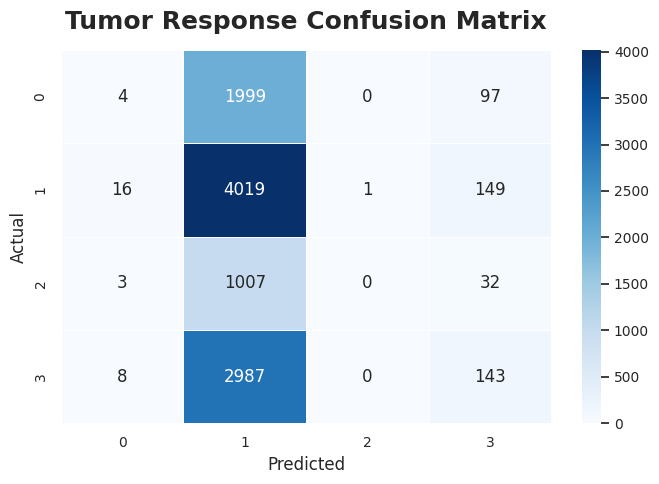


================ FEATURE IMPORTANCE ================

                    Feature  Importance
15          Patient_Segment    0.068512
1                       Sex    0.067004
11         Cycles_Completed    0.065420
4               Cancer_Type    0.064920
7                Tumor_Size    0.064105
14  Overall_Survival_Months    0.063605
8         Metastasis_Status    0.063299
10           Dosage (mg/m²)    0.062544
2                       BMI    0.062509
6               Tumor_Stage    0.061894


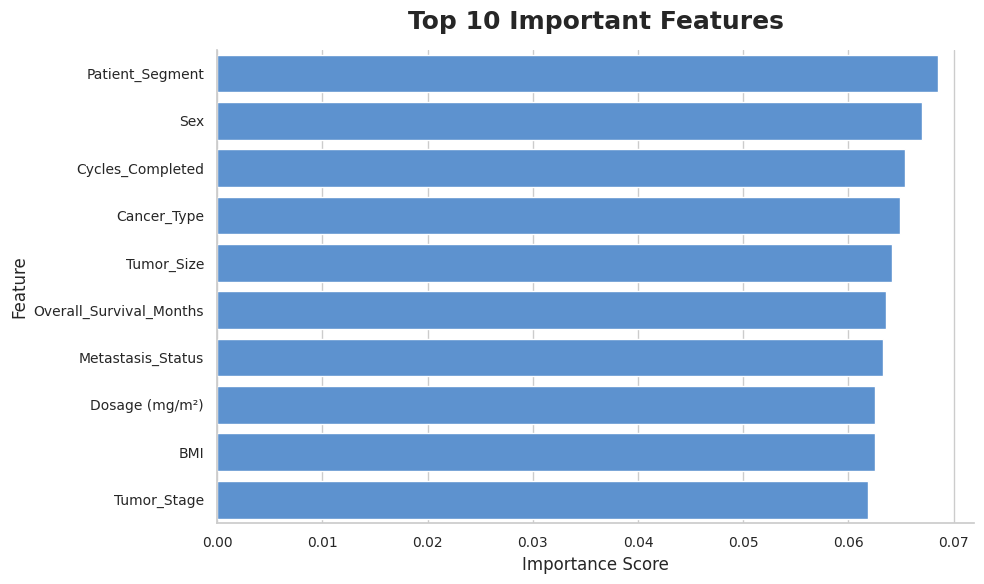


================ SHAP ANALYSIS ================



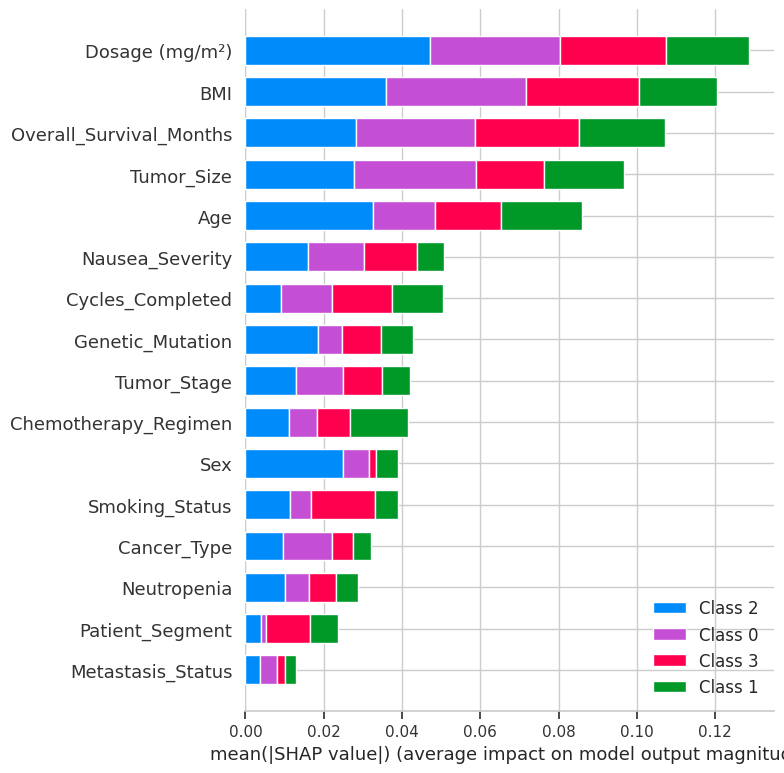


================ BUSINESS INSIGHTS ================

Average Survival by Tumor Stage:

Tumor_Stage
I      62.661250
II     62.552162
III    62.659481
IV     62.037443
Name: Overall_Survival_Months, dtype: float64

Tumor Response Distribution (%):

Tumor_Response
Partial        39.993502
Stable         29.984136
Complete       20.070335
Progressive     9.952027
Name: proportion, dtype: float64

Survival Based on Neutropenia:

Neutropenia
No     62.697592
Yes    62.275921
Name: Overall_Survival_Months, dtype: float64


FINAL CONCLUSION

This project demonstrates how machine learning and healthcare
analytics can support modern oncology treatment analysis.

Key Findings:
1. Tumor stage and metastasis status are important
   clinical predictors.

2. Patient segmentation reveals different survival
   profiles among chemotherapy patients.

3. SHAP analysis improves model explainability and
   supports clinical interpretation.

4. Survival analysis helps identify high-risk groups.

5. Early t

In [9]:
# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install lifelines shap xgboost -q

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

from lifelines import KaplanMeierFitter

import shap

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 3. CLEAN VISUAL STYLE
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['font.family'] = 'sans-serif'

MAIN_BLUE = "#4A90E2"
LIGHT_BLUE = "#A7C7E7"
DARK_BLUE = "#1F4E79"

# ============================================================
# 4. UPLOAD DATASET
# ============================================================

uploaded = files.upload()
df = pd.read_csv('chemotherapy_patient_data.csv')

print("Dataset Loaded Successfully!")
print(df.head())

# ============================================================
# 5. BASIC DATA INFORMATION
# ============================================================

print("\n================ DATA INFO ================\n")
print(df.info())

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())

print("\n================ DESCRIPTIVE STATISTICS ================\n")
print(df.describe())

# ============================================================
# 6. HANDLE MISSING VALUES
# ============================================================

categorical_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill categorical
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Tumor_Response',
    color=MAIN_BLUE,
    edgecolor='none'
)

plt.title(
    'Tumor Response Distribution',
    fontweight='bold',
    pad=15
)

plt.xlabel('Tumor Response')
plt.ylabel('Patient Count')

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 8. CANCER TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Cancer_Type',
    color=MAIN_BLUE,
    edgecolor='none'
)

plt.title(
    'Distribution of Cancer Type',
    fontweight='bold',
    pad=15
)

plt.xlabel('Cancer Type')
plt.ylabel('Patient Count')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 9. SURVIVAL BY CANCER TYPE
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Cancer_Type',
    y='Overall_Survival_Months',
    color=LIGHT_BLUE,
    linewidth=1.2,
    fliersize=2
)

plt.title(
    'Overall Survival by Cancer Type',
    fontweight='bold',
    pad=15
)

plt.xlabel('Cancer Type')
plt.ylabel('Overall Survival (Months)')

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 10. SURVIVAL BASED ON TUMOR STAGE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Tumor_Stage',
    y='Overall_Survival_Months',
    color=LIGHT_BLUE,
    linewidth=1.2,
    fliersize=2
)

plt.title(
    'Survival Based on Tumor Stage',
    fontweight='bold',
    pad=15
)

plt.xlabel('Tumor Stage')
plt.ylabel('Overall Survival (Months)')

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 11. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink':0.8}
)

plt.title(
    'Correlation Heatmap',
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

# ============================================================
# 12. SURVIVAL ANALYSIS
# ============================================================

print("\n================ SURVIVAL ANALYSIS ================\n")

kmf = KaplanMeierFitter()

survival_time = df['Overall_Survival_Months']

# Simulasi event
event_observed = np.where(df['Tumor_Response'] == 'Progressive', 1, 0)

kmf.fit(survival_time, event_observed)

plt.figure(figsize=(8,5))

kmf.plot_survival_function(
    ci_show=False,
    color=MAIN_BLUE,
    linewidth=2
)

plt.title(
    'Kaplan-Meier Survival Curve',
    fontweight='bold',
    pad=15
)

plt.xlabel('Months')
plt.ylabel('Survival Probability')

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 13. PATIENT SEGMENTATION
# ============================================================

print("\n================ PATIENT SEGMENTATION ================\n")

segmentation_features = df[[
    'Age',
    'BMI',
    'Tumor_Size',
    'Dosage (mg/m²)',
    'Overall_Survival_Months'
]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Patient_Segment'] = kmeans.fit_predict(segmentation_features)

print(df['Patient_Segment'].value_counts())

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Tumor_Size'],
    y=df['Overall_Survival_Months'],
    hue=df['Patient_Segment'],
    palette='Blues',
    s=60,
    alpha=0.7,
    edgecolor='none'
)

plt.title(
    'Patient Segmentation',
    fontweight='bold',
    pad=15
)

plt.xlabel('Tumor Size')
plt.ylabel('Overall Survival (Months)')

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 14. MACHINE LEARNING PREPARATION
# ============================================================

print("\n================ MACHINE LEARNING ================\n")

model_df = df.copy()

# Encode categorical variables
label_encoders = {}

for col in model_df.select_dtypes(include='object').columns:

    le = LabelEncoder()

    model_df[col] = le.fit_transform(model_df[col])

    label_encoders[col] = le

# ============================================================
# 15. DEFINE FEATURES & TARGET
# ============================================================

X = model_df.drop([
    'Tumor_Response',
    'Patient_ID'
], axis=1)

y = model_df['Tumor_Response']

# ============================================================
# 16. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# 17. XGBOOST MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 18. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}\n")

print("================ CLASSIFICATION REPORT ================\n")
print(classification_report(y_test, y_pred))

# ============================================================
# 19. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title(
    'Tumor Response Confusion Matrix',
    fontweight='bold',
    pad=15
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n================ FEATURE IMPORTANCE ================\n")
print(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature',
    color=MAIN_BLUE
)

plt.title(
    'Top 10 Important Features',
    fontweight='bold',
    pad=15
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')

sns.despine()

plt.tight_layout()
plt.show()

# ============================================================
# 21. SHAP ANALYSIS
# ============================================================

print("\n================ SHAP ANALYSIS ================\n")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

# ============================================================
# 22. BUSINESS INSIGHTS
# ============================================================

print("\n================ BUSINESS INSIGHTS ================\n")

# Average survival by stage
stage_survival = df.groupby('Tumor_Stage')[
    'Overall_Survival_Months'
].mean()

print("Average Survival by Tumor Stage:\n")
print(stage_survival)

# Response distribution
response_distribution = (
    df['Tumor_Response']
    .value_counts(normalize=True) * 100
)

print("\nTumor Response Distribution (%):\n")
print(response_distribution)

# Neutropenia impact
neutro_survival = df.groupby('Neutropenia')[
    'Overall_Survival_Months'
].mean()

print("\nSurvival Based on Neutropenia:\n")
print(neutro_survival)

# ============================================================
# 23. FINAL CONCLUSION
# ============================================================

print("""

===========================================================
FINAL CONCLUSION
===========================================================

This project demonstrates how machine learning and healthcare
analytics can support modern oncology treatment analysis.

Key Findings:
1. Tumor stage and metastasis status are important
   clinical predictors.

2. Patient segmentation reveals different survival
   profiles among chemotherapy patients.

3. SHAP analysis improves model explainability and
   supports clinical interpretation.

4. Survival analysis helps identify high-risk groups.

5. Early toxicity prediction may reduce severe
   chemotherapy complications and hospitalization.

""")